#   LAB 04 - Data Mining

#   Exercise 1-2

In [187]:
# LOAD ALL LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from seaborn import heatmap
import seaborn as sns
%matplotlib inline

## Read file excel

Load the file into the Disk on the left in the File Section (Folder Icon). Next, read the file using pandas by passing the path.

In [188]:
df = pd.read_excel('breast.xlsx')

In a Jupyter Notebook cell, you can print a subset of the representation by simply calling the name of the variable containing the DataFrame.

In [189]:
# print dataset
df

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,'40-49','premeno','15-19','0-2','yes','3','right','left_up','no','recurrence-events'
1,'50-59','ge40','15-19','0-2','no','1','right','central','no','no-recurrence-events'
2,'50-59','ge40','35-39','0-2','no','2','left','left_low','no','recurrence-events'
3,'40-49','premeno','35-39','0-2','yes','3','right','left_low','yes','no-recurrence-events'
4,'40-49','premeno','30-34','3-5','yes','2','left','right_up','no','recurrence-events'
...,...,...,...,...,...,...,...,...,...,...
281,'50-59','ge40','30-34','6-8','yes','2','left','left_low','no','no-recurrence-events'
282,'50-59','premeno','25-29','3-5','yes','2','left','left_low','yes','no-recurrence-events'
283,'30-39','premeno','30-34','6-8','yes','2','right','right_up','no','no-recurrence-events'
284,'50-59','premeno','15-19','0-2','no','2','right','left_low','no','no-recurrence-events'


Remove duplicated elements

In [190]:
df = df.drop_duplicates()

## Select Label and apply encoding

Separate the dataset into features, referred to as X, and labels, referred to as y.


In [191]:
X = df.drop('Class', axis=1)
y = df['Class']

Afterwards, utilize Label Encoder to encode the categorical features.

In [192]:
encoder = LabelEncoder()
for col in X.columns:
    X[col] = encoder.fit_transform(X[col])
y = encoder.fit_transform(y)

##  Use the decision tree classifier model.

[Use DecisionTreeClassifier() and its .fit function]

In [193]:
# Initialize the Decision Tree Classifier, set max depth
clf = DecisionTreeClassifier(max_depth=5)
# Train the Decision Tree Classifier
clf.fit(X, y)

DecisionTreeClassifier(max_depth=5)

Obiettivo: Controllare la complessità del modello (profondità) e vedere l’accuratezza complessiva sul set di addestramento.

##  Print the structure of the decision tree

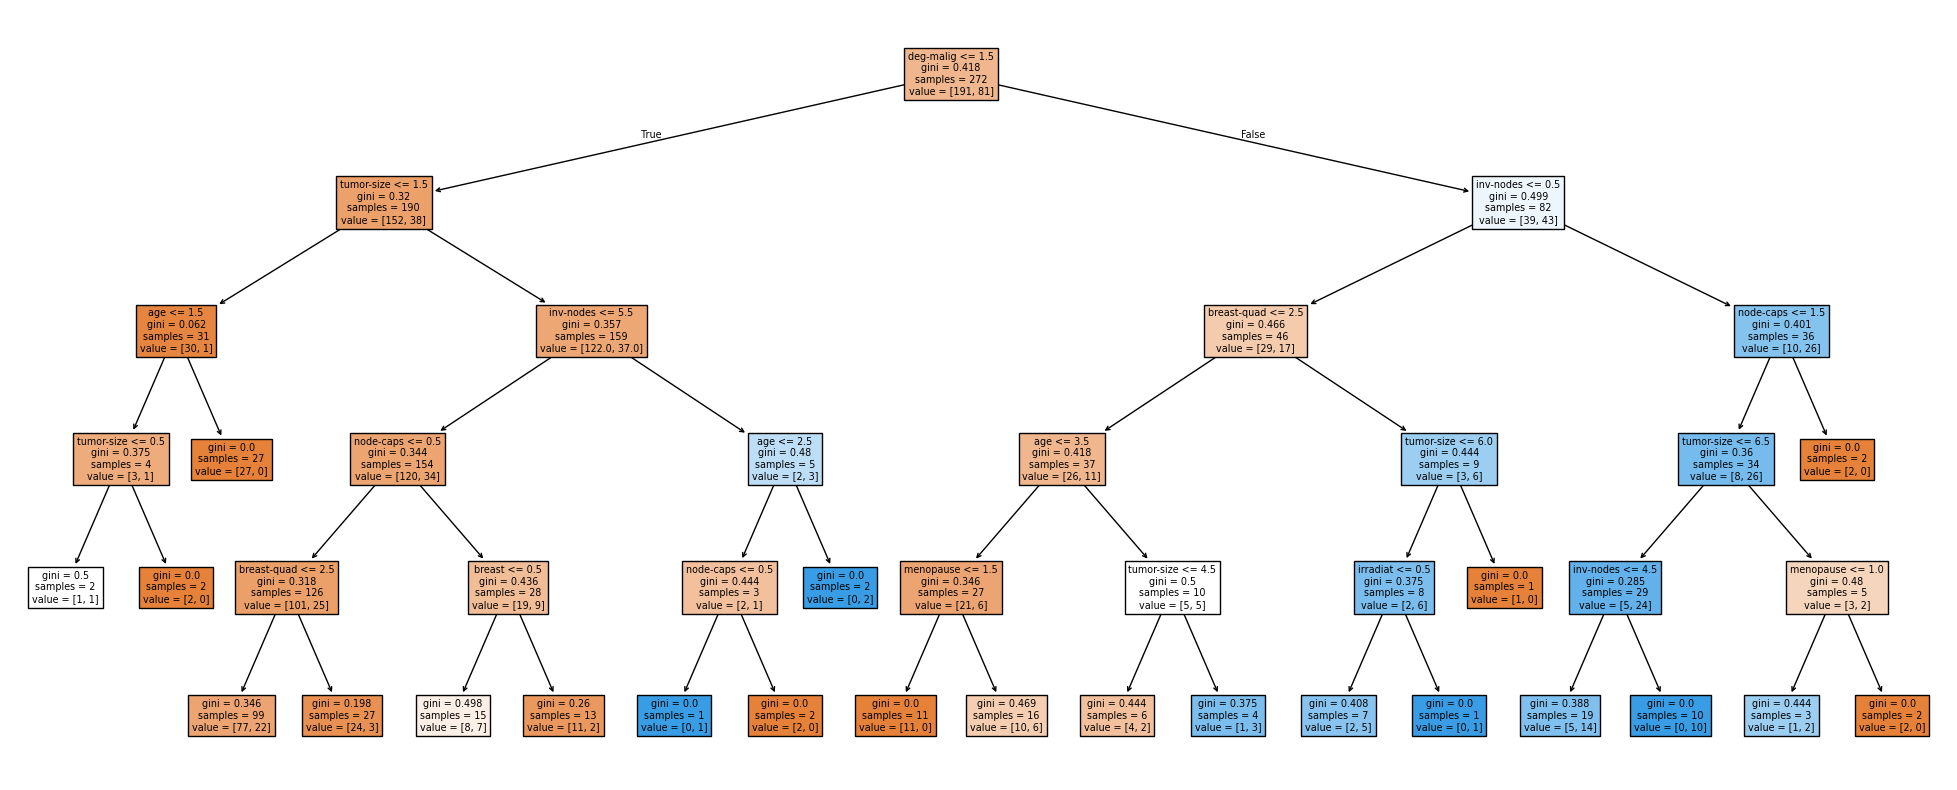

In [194]:
# Define figure
plt.figure(figsize=(25, 10))
# Print Tree
plot_tree(clf, filled=True, feature_names=X.columns)
# use plot_tree from sklearn
plt.show()

In [195]:
# Decision tree depth
clf.get_depth()

5

## Impact Parameters

Evaluate the Tree by combining differen max depth and min impurity values

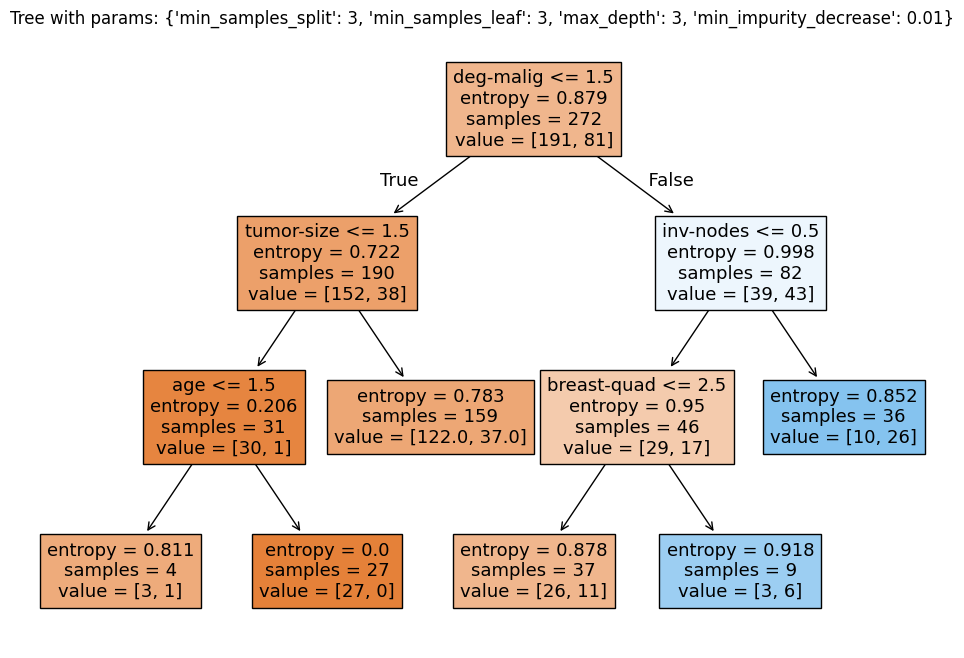

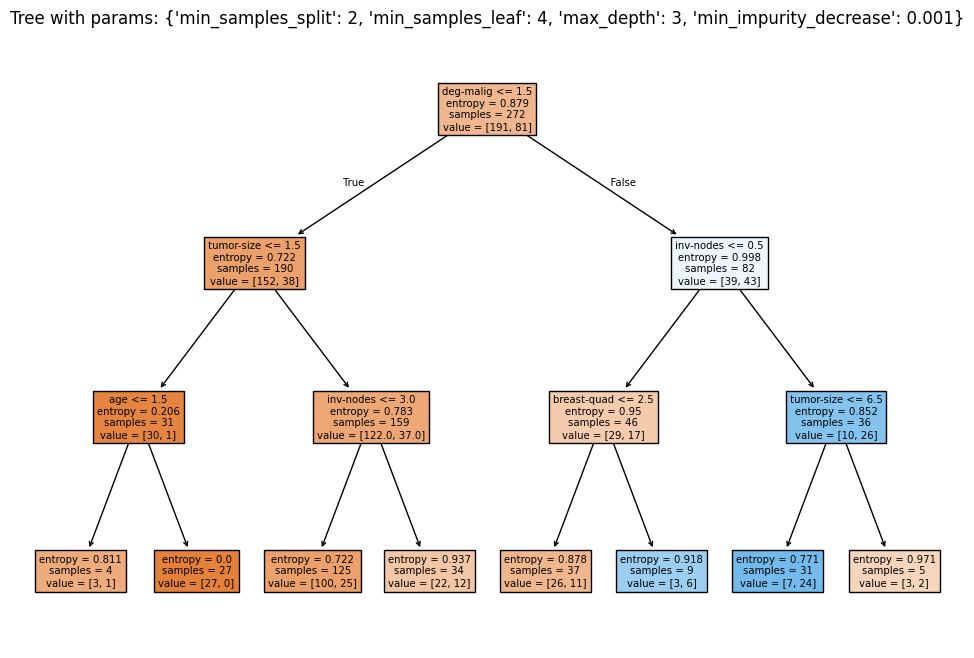

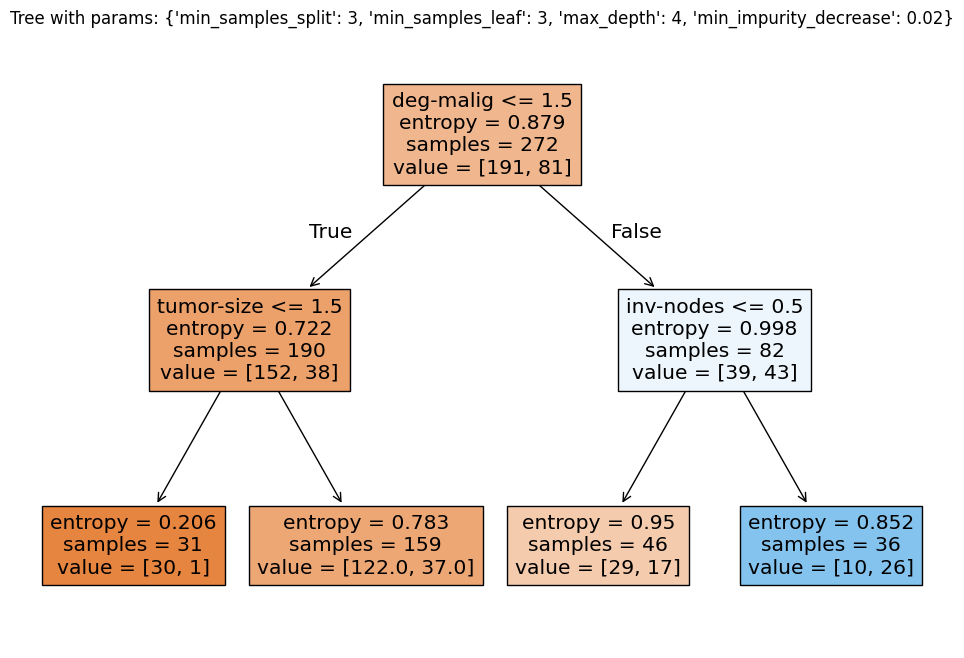

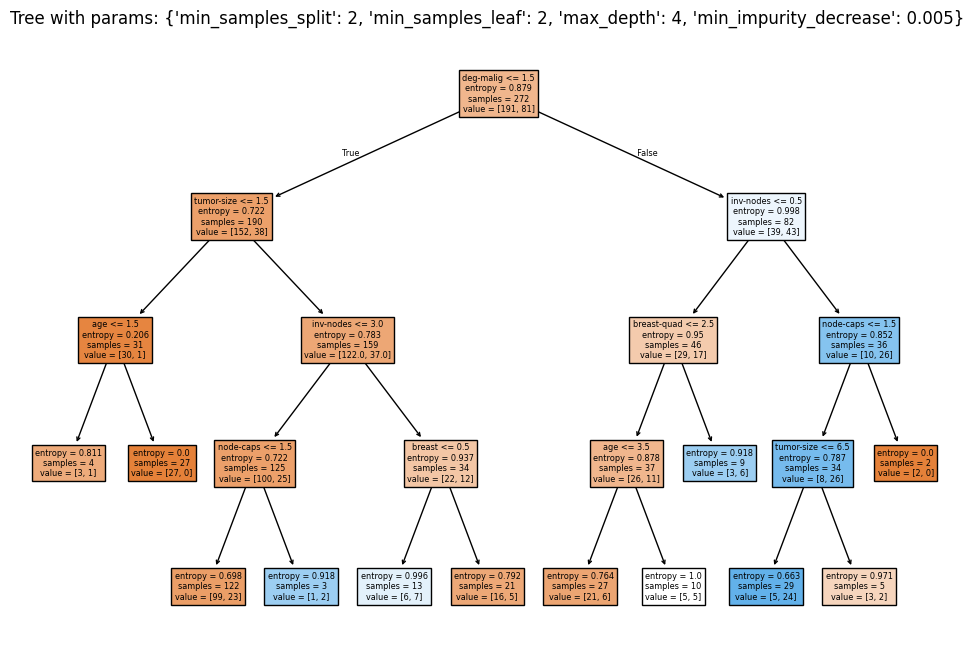

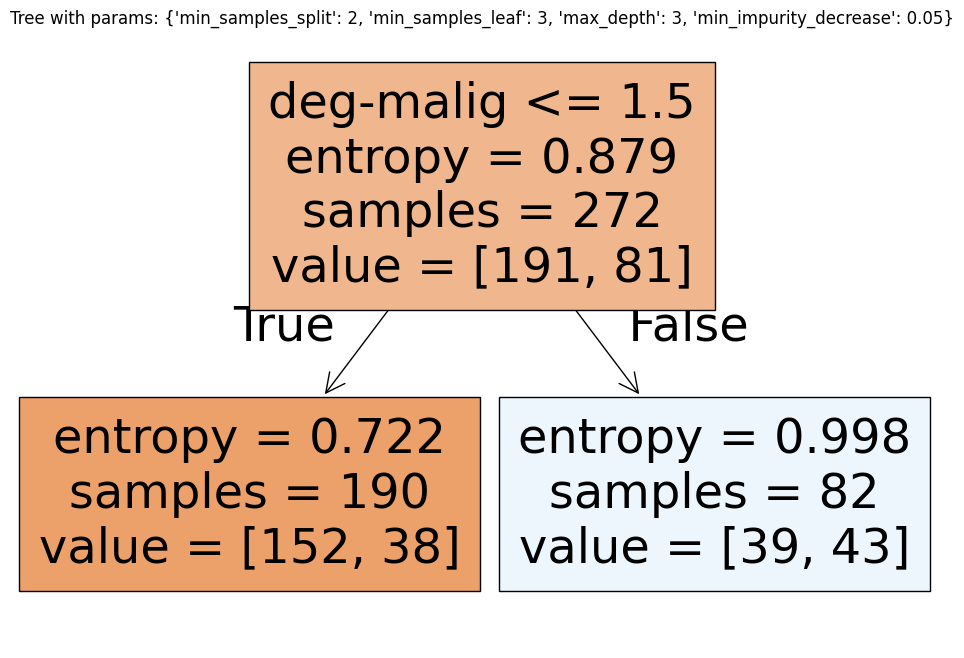

In [196]:
parameters = [
    {"min_samples_split": 3, "min_samples_leaf": 3, "max_depth": 3, "min_impurity_decrease": 0.01},
    {"min_samples_split": 2, "min_samples_leaf": 4, "max_depth": 3, "min_impurity_decrease": 0.001},
    {"min_samples_split": 3, "min_samples_leaf": 3, "max_depth": 4, "min_impurity_decrease": 0.02},
    {"min_samples_split": 2, "min_samples_leaf": 2, "max_depth": 4, "min_impurity_decrease": 0.005},
    {"min_samples_split": 2, "min_samples_leaf": 3, "max_depth": 3, "min_impurity_decrease": 0.05},
]

for param in parameters:
    clf = DecisionTreeClassifier(
        criterion='entropy',
        min_samples_split=param["min_samples_split"],
        min_samples_leaf=param["min_samples_leaf"],
        max_depth=param["max_depth"],
        min_impurity_decrease=param["min_impurity_decrease"],
    )

    clf.fit(X, y)

    plt.figure(figsize=(12, 8))
    plot_tree(clf, feature_names=X.columns, filled=True)
    plt.title(f"Tree with params: {param}")
    plt.show()

# Exercise 3-4

## Validation of a classification model using Cross Validation

Cross-validation is a technique used to assess the performance and generalization ability of machine learning models, particularly in the context of classification tasks. It involves partitioning the dataset into multiple subsets, known as folds.

1. **Partitioning the Dataset**: The dataset is divided into k equal-sized folds.

2. **Training and Testing**: The model is trained k times, each time using k-1 folds for training and the remaining fold for testing.

3. **Evaluation**: The performance of the model is evaluated on each fold, and the results are averaged to obtain a robust estimate of the model's performance.

4. **Advantages**: Cross-validation provides a more reliable estimate of the model's performance compared to a single train-test split. It helps to detect overfitting and assesses the model's ability to generalize to unseen data.

[Use `cross_val_score` and `cross_val_predict` to perform cross-validation easily. Follow the same instruction of Exercise 1 to initialise and use the model]

In [197]:
parameters = [
    {"min_samples_split": 3, "min_samples_leaf": 3, "max_depth": 3, "min_impurity_decrease": 0.01},
    {"min_samples_split": 2, "min_samples_leaf": 4, "max_depth": 3, "min_impurity_decrease": 0.001},
    {"min_samples_split": 3, "min_samples_leaf": 3, "max_depth": 4, "min_impurity_decrease": 0.02},
    {"min_samples_split": 2, "min_samples_leaf": 2, "max_depth": 4, "min_impurity_decrease": 0.005},
    {"min_samples_split": 2, "min_samples_leaf": 3, "max_depth": 3, "min_impurity_decrease": 0.05},
]

skf = StratifiedKFold(n_splits=10, shuffle=True)

for param in parameters:
    clf = DecisionTreeClassifier(
        criterion='entropy',
        min_samples_split=param["min_samples_split"],
        min_samples_leaf=param["min_samples_leaf"],
        max_depth=param["max_depth"],
        min_impurity_decrease=param["min_impurity_decrease"],
    )

    scores = cross_val_score(clf, X, y, cv=skf)
    print(f"Average accuracy for params {param}:\n{scores.mean()}")

    y_pred = cross_val_predict(clf, X, y, cv=skf)
    cm = confusion_matrix(y, y_pred)
    print(f"Confusion matrix for params {param}:")
    print(cm)
    print()

Average accuracy for params {'min_samples_split': 3, 'min_samples_leaf': 3, 'max_depth': 3, 'min_impurity_decrease': 0.01}:
0.7134920634920634
Confusion matrix for params {'min_samples_split': 3, 'min_samples_leaf': 3, 'max_depth': 3, 'min_impurity_decrease': 0.01}:
[[174  17]
 [ 59  22]]

Average accuracy for params {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'min_impurity_decrease': 0.001}:
0.7354497354497355
Confusion matrix for params {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'min_impurity_decrease': 0.001}:
[[172  19]
 [ 54  27]]

Average accuracy for params {'min_samples_split': 3, 'min_samples_leaf': 3, 'max_depth': 4, 'min_impurity_decrease': 0.02}:
0.7425925925925926
Confusion matrix for params {'min_samples_split': 3, 'min_samples_leaf': 3, 'max_depth': 4, 'min_impurity_decrease': 0.02}:
[[176  15]
 [ 57  24]]

Average accuracy for params {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 4, 'min_impurity_decrease': 0.005}:


In [198]:
# Initialize the KNN classifier
neighbors = [3, 4, 5, 6, 7]

# Perform StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform cross-validation predictions
skf = StratifiedKFold(n_splits=10)
for n in neighbors:
    clf = KNeighborsClassifier(n_neighbors=n)
    scores = cross_val_score(clf, X_scaled, y, cv=skf)

    print(f"KNN Neighbors: {n}")

    # Confusion matrix
    y_pred = cross_val_predict(clf, X_scaled, y, cv=skf)
    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Evaluate accuracy
    print(f"Accuracy: {scores.mean()}")
    print()

KNN Neighbors: 3
Confusion Matrix:
[[165  26]
 [ 56  25]]
Accuracy: 0.6985449735449736

KNN Neighbors: 4
Confusion Matrix:
[[178  13]
 [ 65  16]]
Accuracy: 0.7134920634920635

KNN Neighbors: 5
Confusion Matrix:
[[171  20]
 [ 58  23]]
Accuracy: 0.7134920634920635

KNN Neighbors: 6
Confusion Matrix:
[[177  14]
 [ 65  16]]
Accuracy: 0.7099206349206348

KNN Neighbors: 7
Confusion Matrix:
[[170  21]
 [ 61  20]]
Accuracy: 0.6986772486772488



In [199]:
# Initialize the Naive Bayes classifier
clf = GaussianNB()

# Perform cross-validation predictions
skf = StratifiedKFold(n_splits=10)
scores = cross_val_score(clf, X, y, cv=skf)

# Confusion matrix
y_pred = cross_val_predict(clf, X, y, cv=skf)
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

# Evaluate accuracy
print(f"Accuracy: {scores.mean()}")
print()

Confusion Matrix:
[[157  34]
 [ 41  40]]
Accuracy: 0.725



# Exercise 5

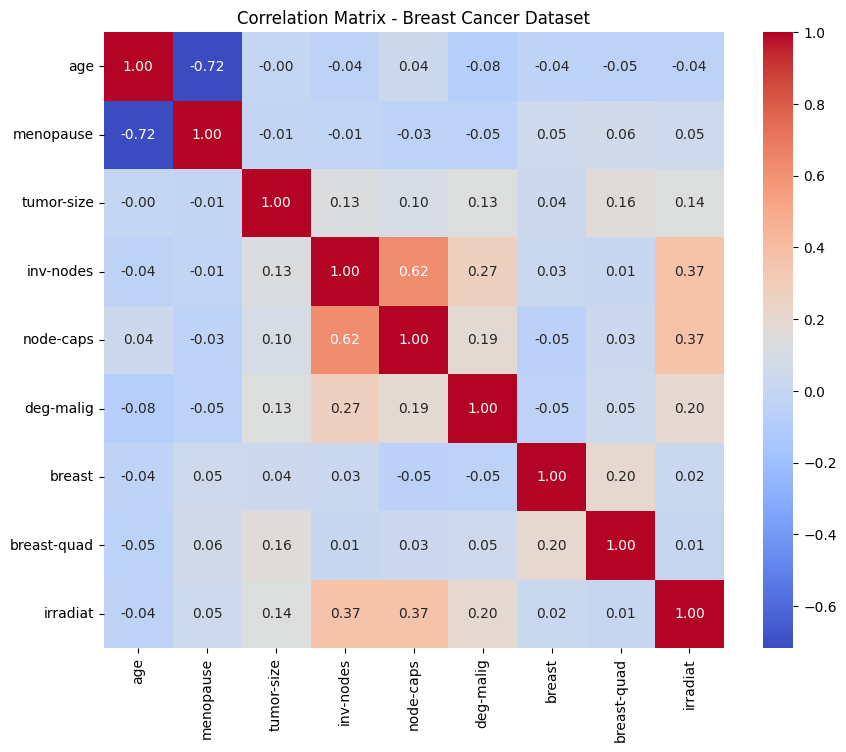

In [200]:
# Perform Correlation Analysis
correlation_matrix = X.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Matrix - Breast Cancer Dataset')
plt.show()